In [38]:
from model_ranking import (
    load_h5,
    get_roi_slice
)
import matplotlib.pyplot as plt
import numpy as np

In [39]:
H_gt_path = "/scratch/talks/data/Rmito/test_converted.h5"
gt_key = "labels"
raw_key = "raw"

# VtoR_def_V_model_Res1

In [40]:
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned_fullslice/VtoR_def_V_model_Res1/norm_Normalize/none/predictions/test_converted_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned_fullslice/VtoR_def_V_model_Res1/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [41]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

In [42]:
nan_ids = np.where(np.isnan(EI_consis))[0]
print(len(nan_ids))

0


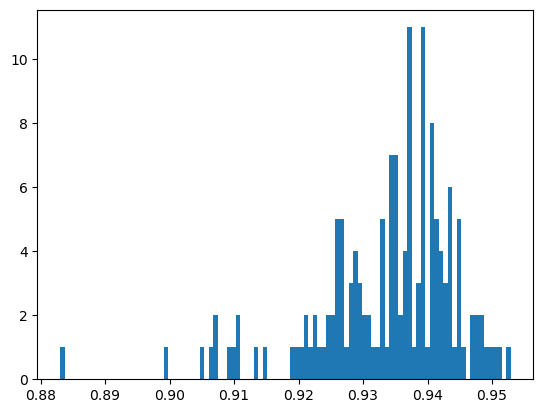

In [43]:
plt.hist(EI_consis, bins=100)
plt.show()

In [44]:
nan_f1s = np.where(np.isnan(F1_scores[:, 1]))[0]
print(len(nan_f1s))

0


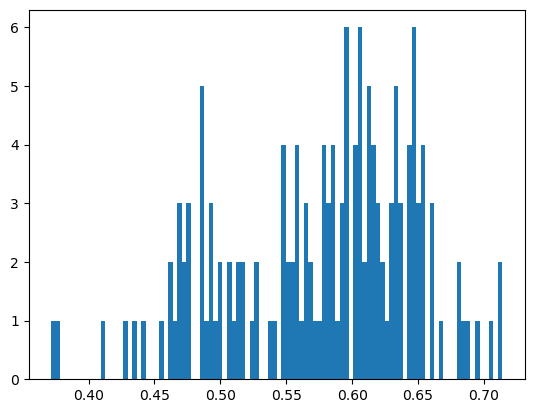

In [45]:
plt.hist(F1_scores[:, 1], bins=100)
plt.show()

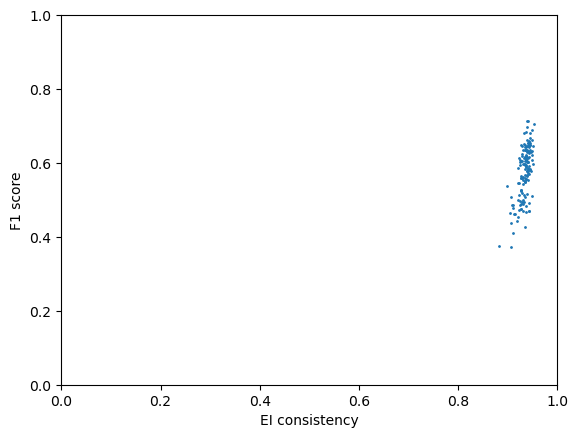

In [46]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.xlabel("EI consistency")
plt.ylabel("F1 score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [10]:
f1_zero_ids = np.where(F1_scores[:, 1] == 0)[0]
print(len(f1_zero_ids))

324


In [11]:
f1_ids_not_zero = np.where(F1_scores[:, 1] != 0)[0]
print(len(f1_ids_not_zero))

3426


In [12]:
np.nanmedian(EI_consis)

0.9345507

In [13]:
np.median(EI_consis[f1_ids_not_zero])

0.9364443

In [14]:
patch_indxs[0]

array([[  0,   1],
       [  0, 256],
       [  0, 256]])

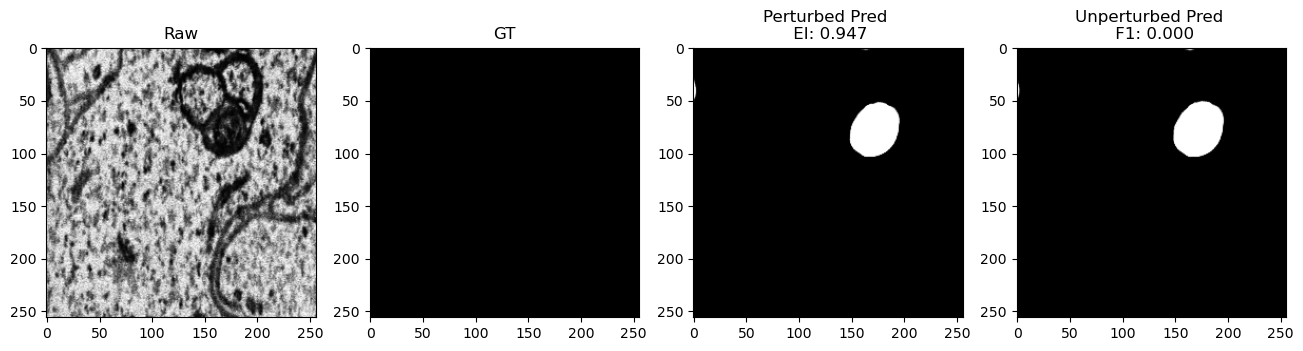

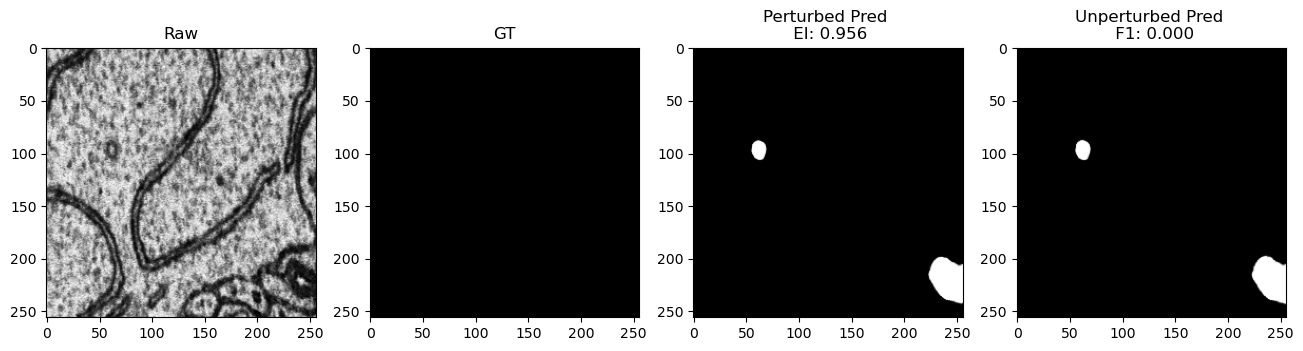

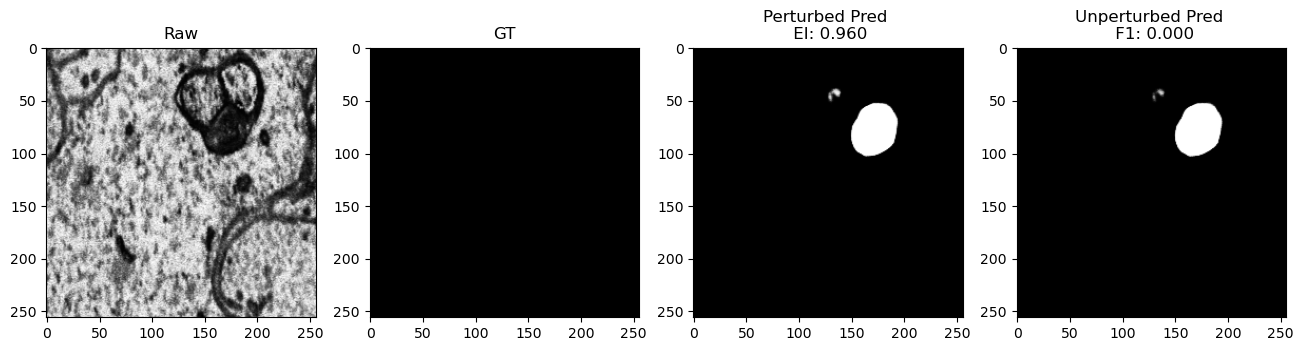

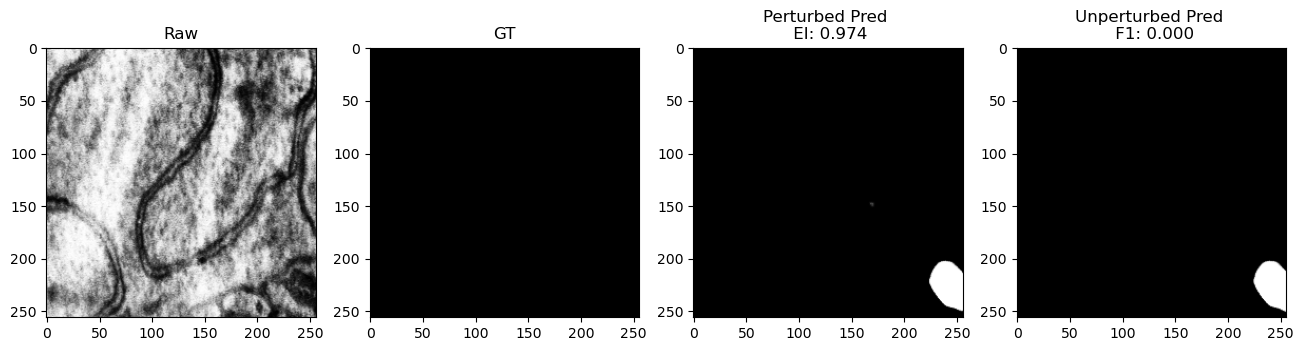

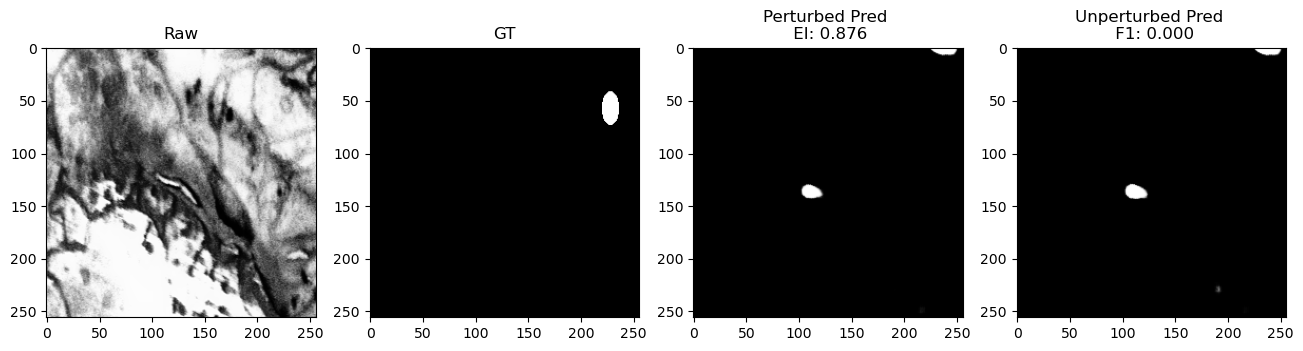

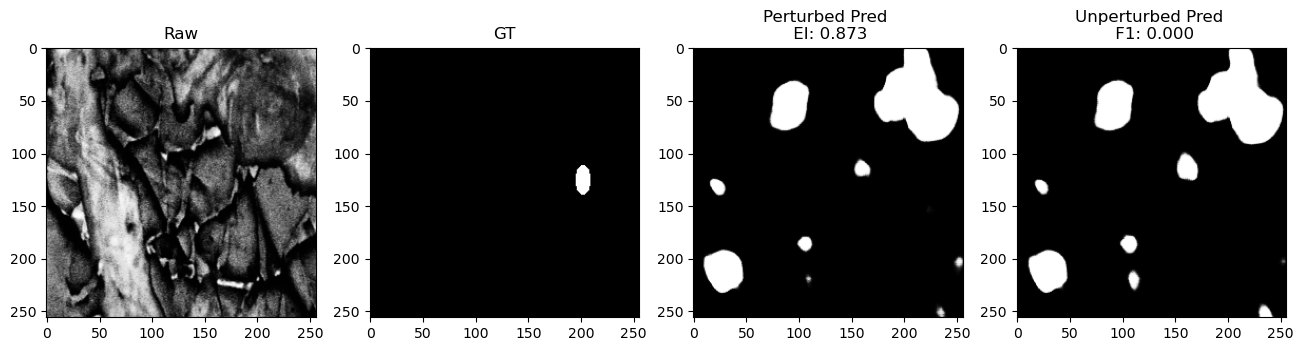

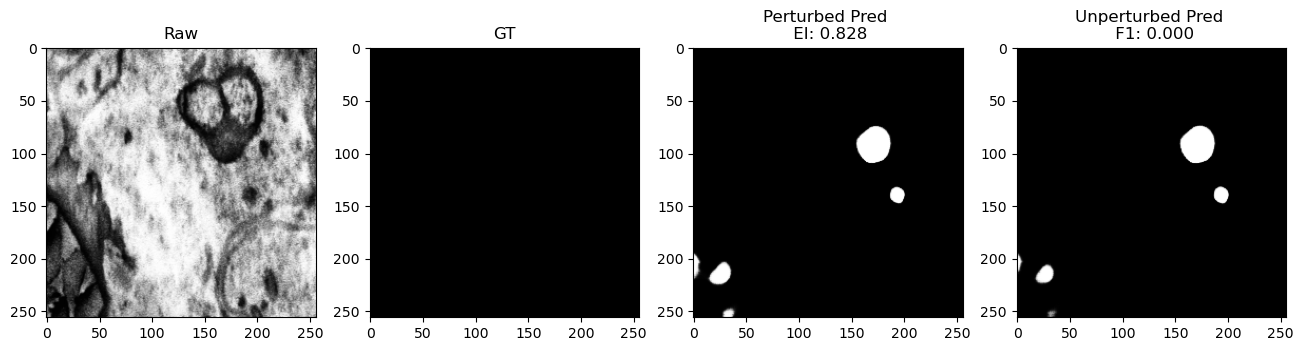

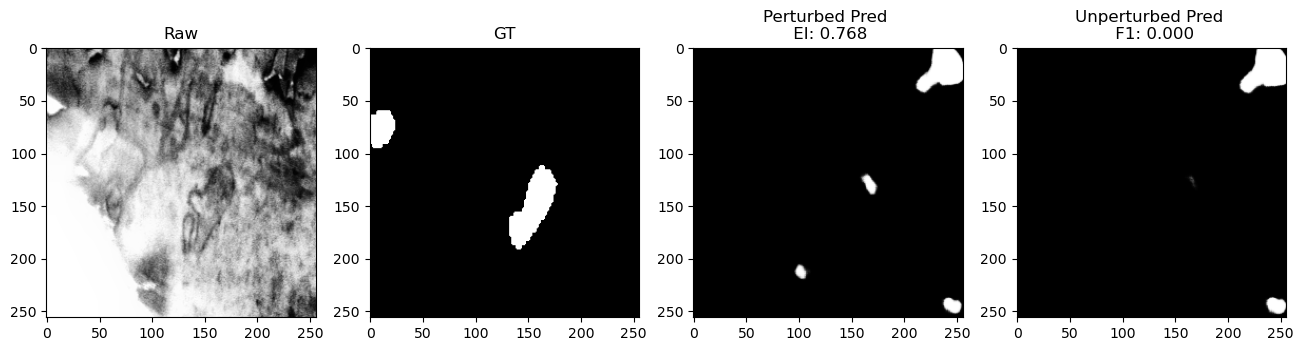

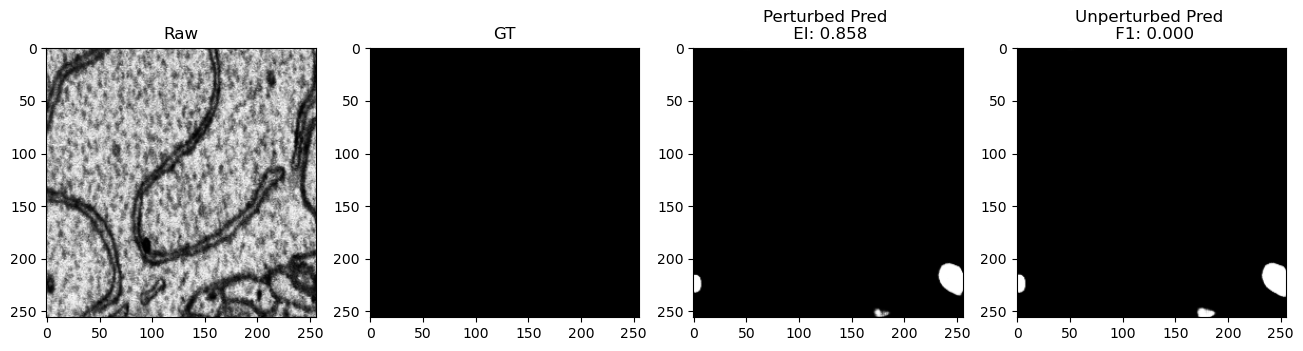

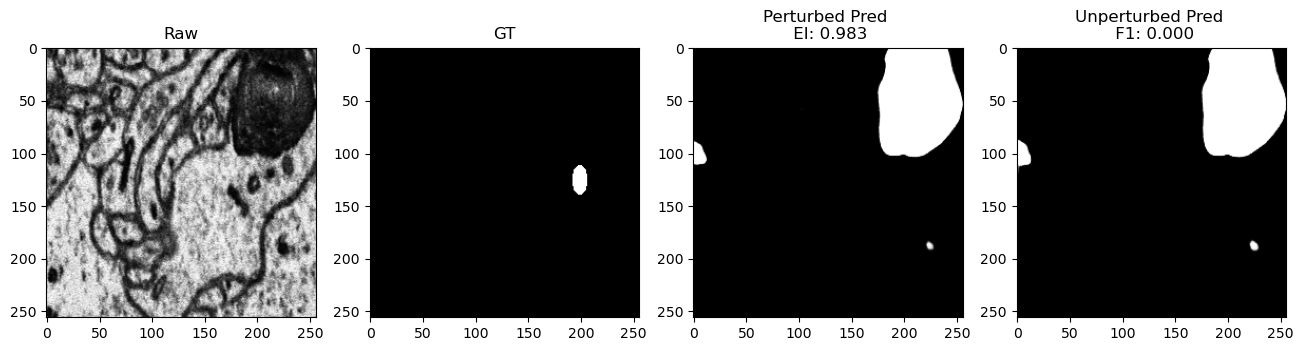

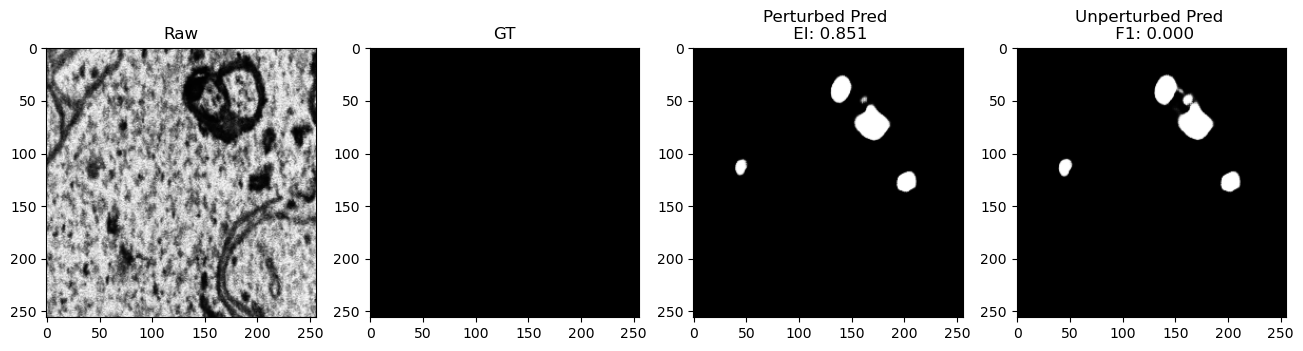

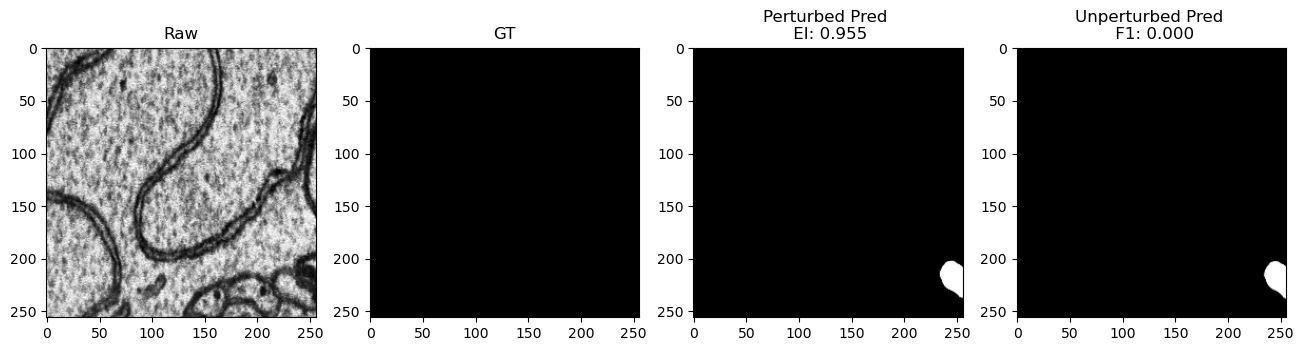

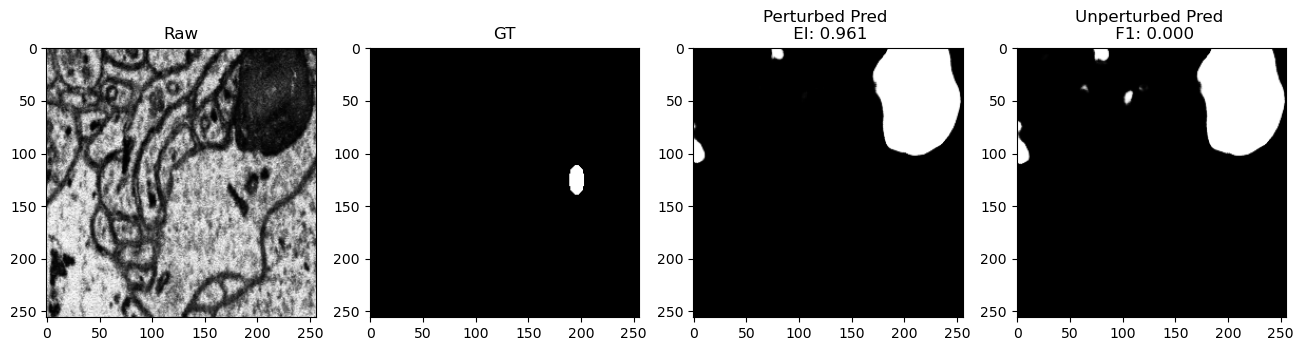

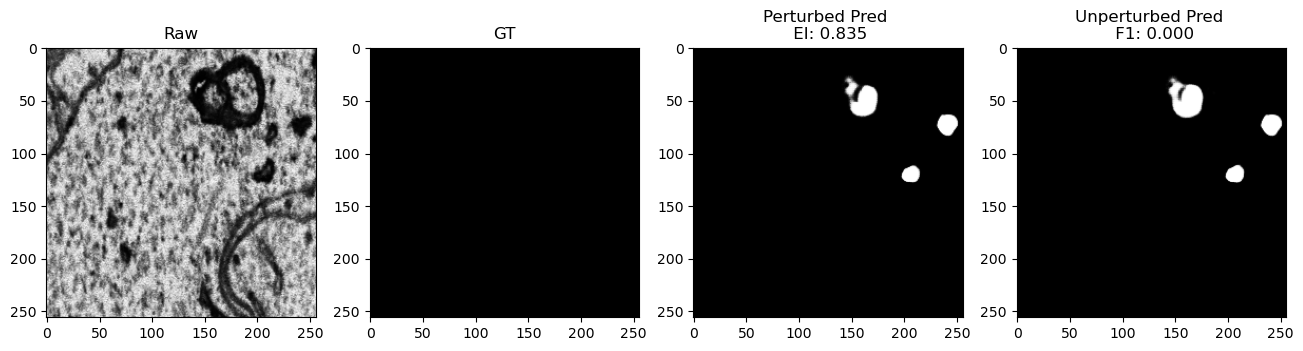

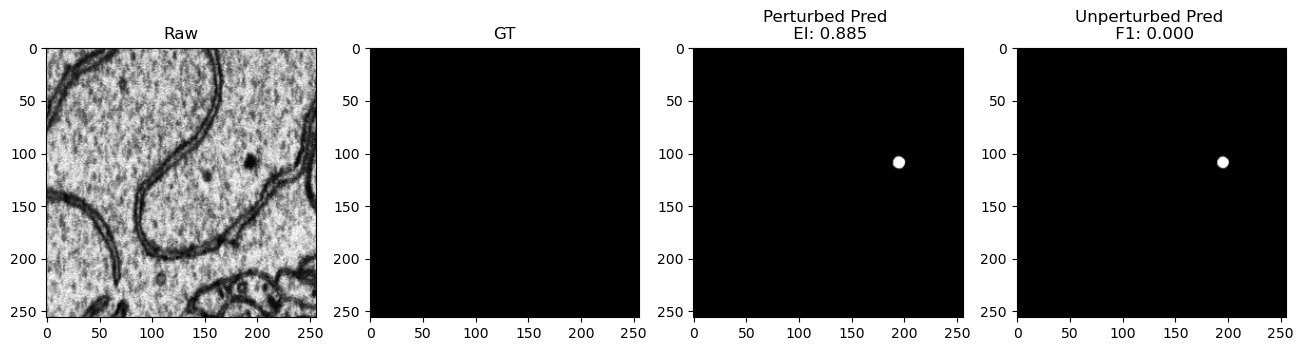

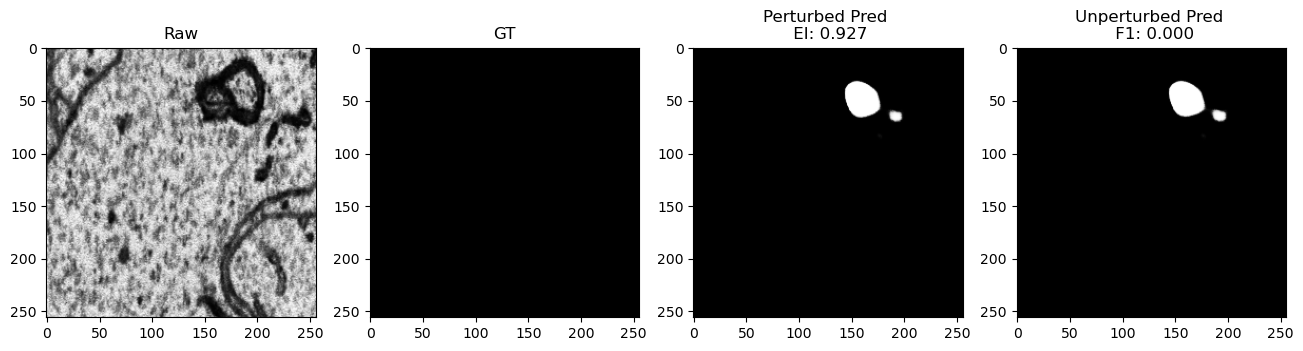

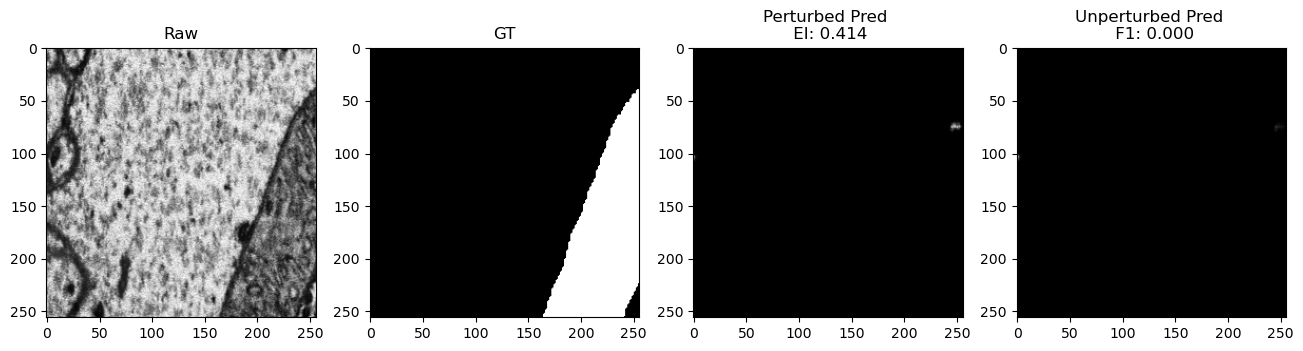

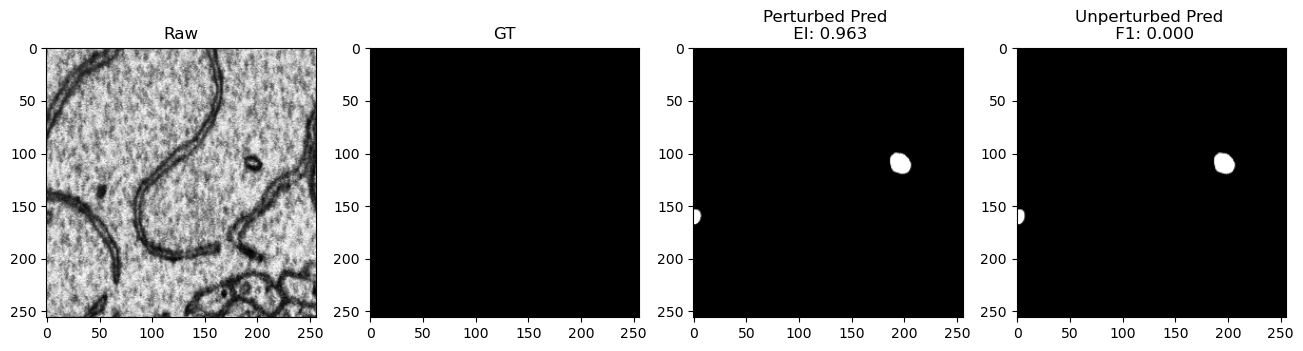

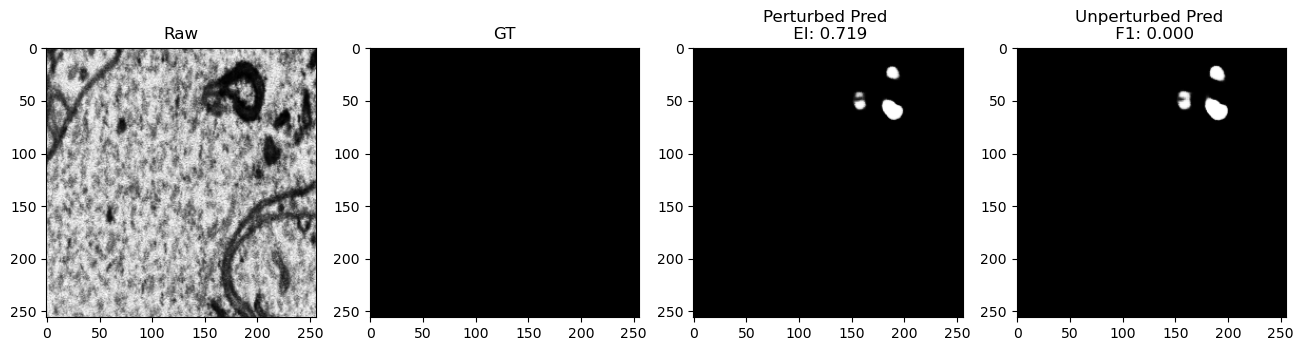

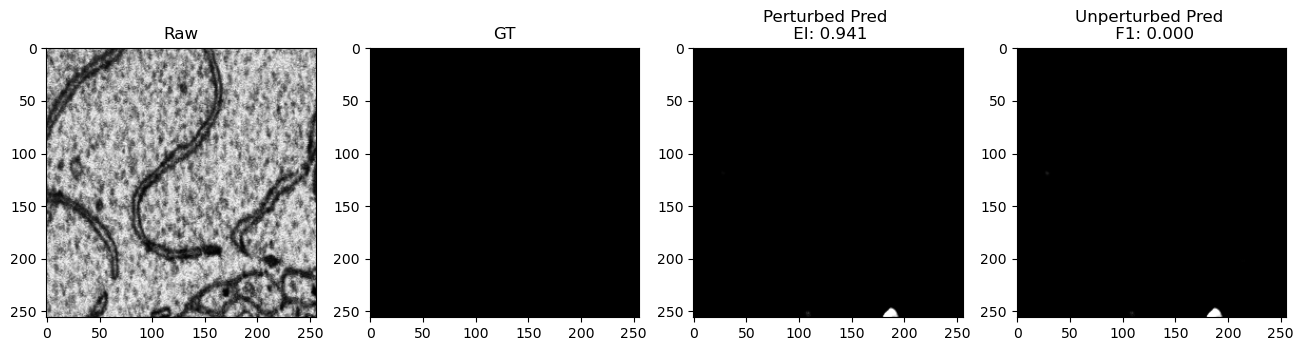

In [15]:
offset = 20
for i in f1_zero_ids[offset:offset+20]:
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(H_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(H_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()

# VtoR_def_V_model_NA2

In [29]:
p_path ="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned/VtoR_def_V_model_NA2/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned/VtoR_def_V_model_NA2/norm_Normalize/none/predictions/test_converted_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [30]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

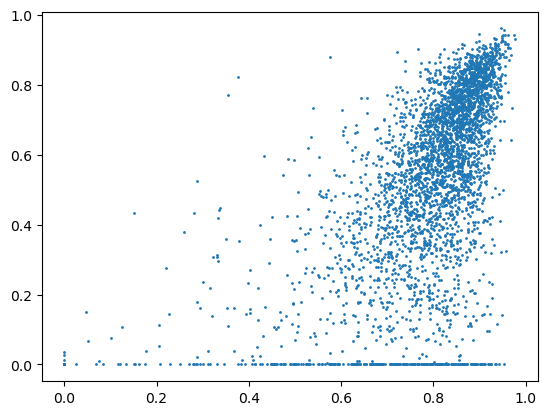

In [31]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.show()

In [32]:
zero_f1_ids = np.where(F1_scores[:, 1] == 0)[0]
print(len(zero_f1_ids))

332


In [33]:
f1_ids_not_zero = np.where(F1_scores[:, 1] != 0)[0]
print(len(f1_ids_not_zero))

3418


In [34]:
np.nanmedian(EI_consis)

0.8271355

In [35]:
np.nanmedian(EI_consis[f1_ids_not_zero])

0.8321666

In [36]:
low_f1_high_consis_ids = np.where((F1_scores[:, 1] < 0.2) & (F1_scores[:, 1] > 0) & (EI_consis > 0.8))[0]
print(len(low_f1_high_consis_ids))

68


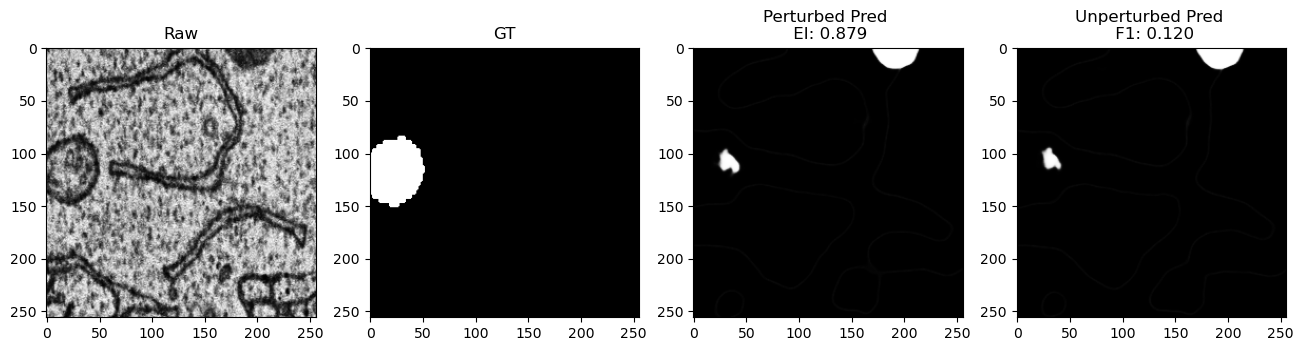

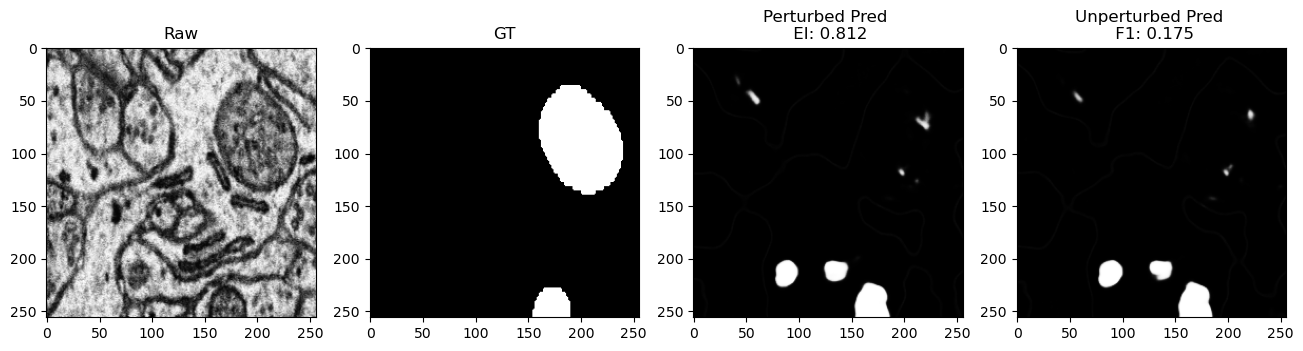

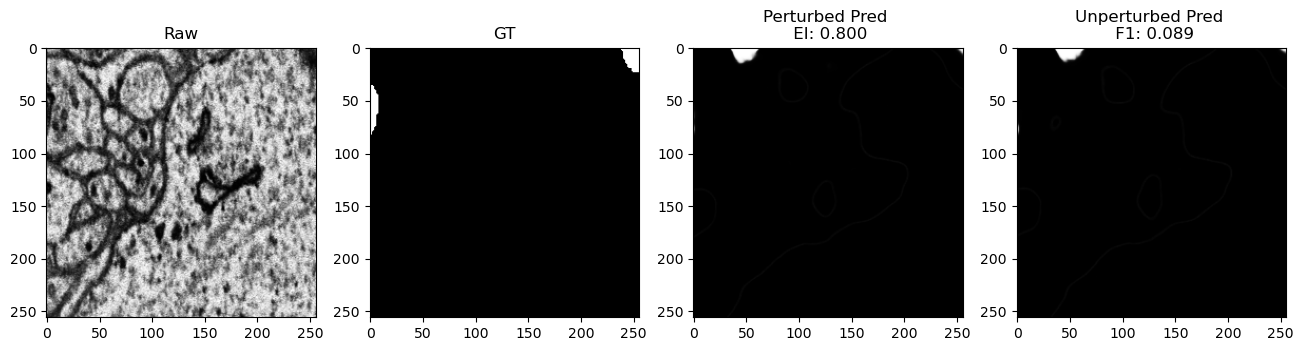

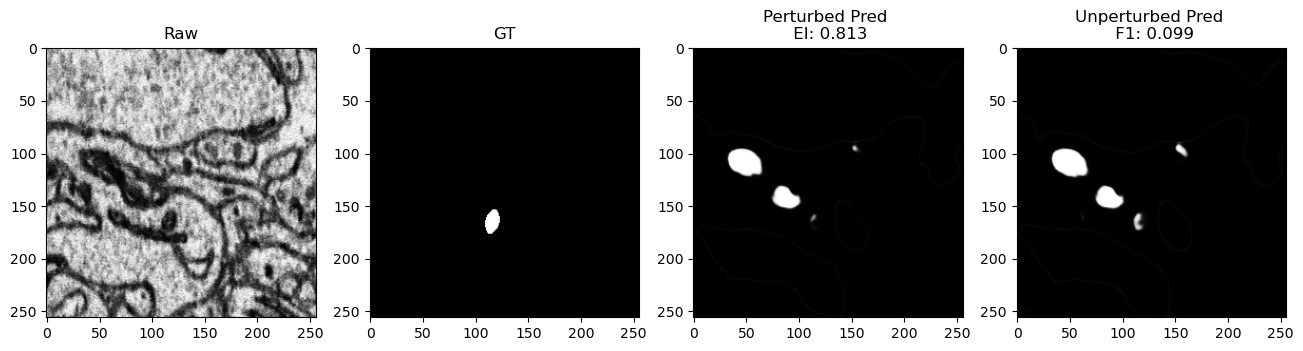

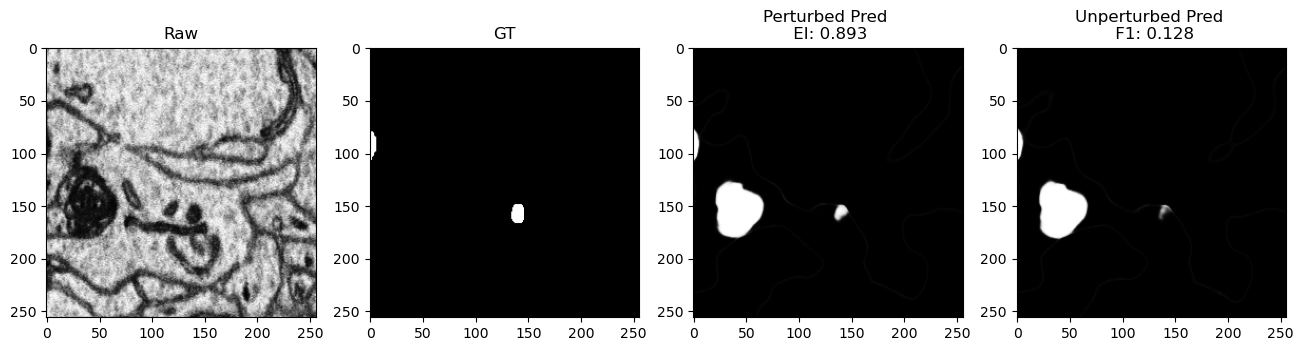

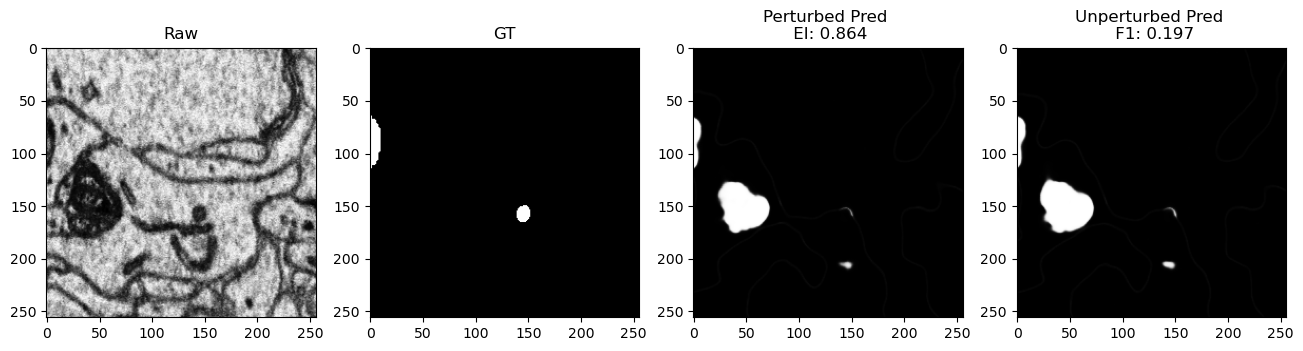

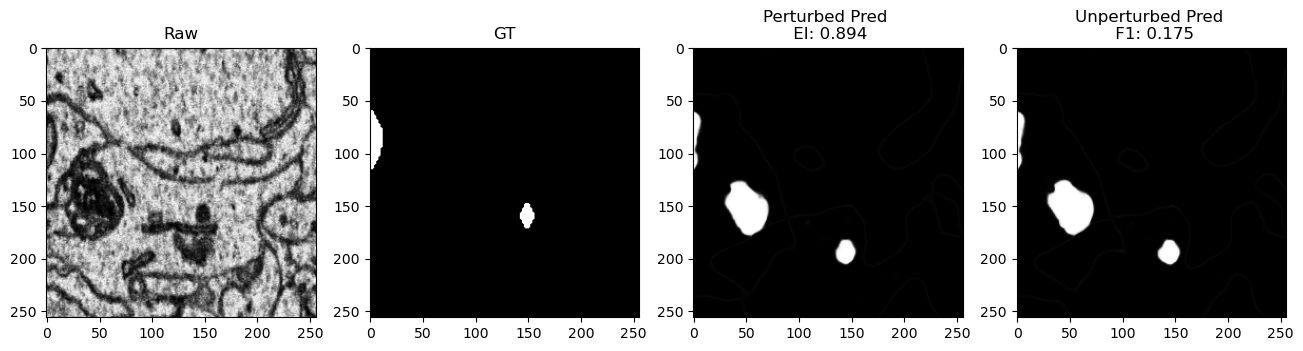

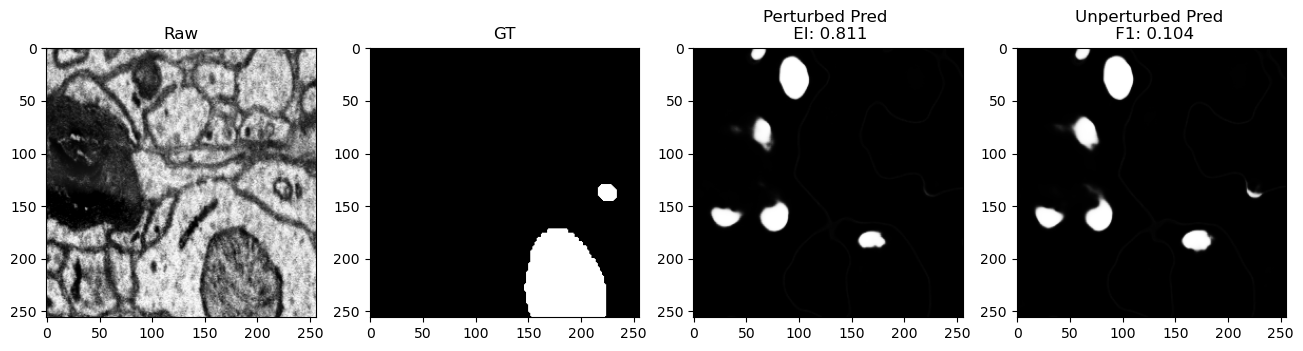

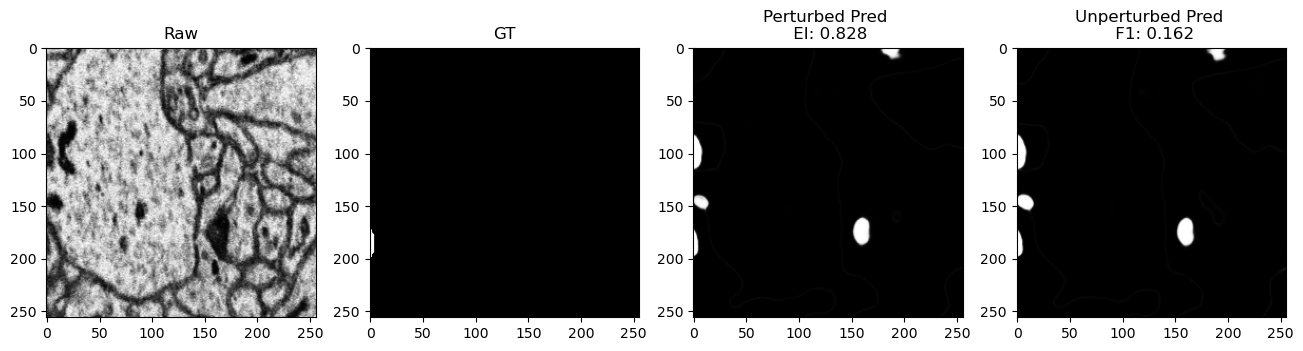

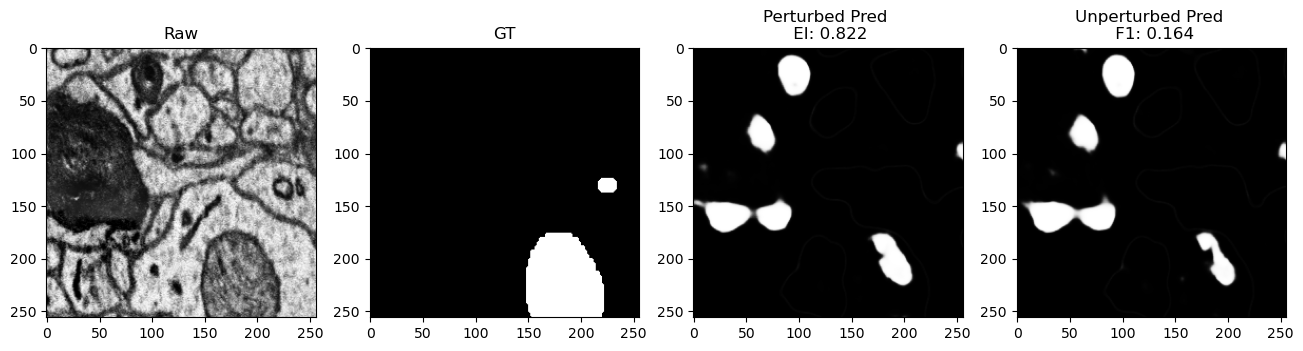

In [37]:
offset = 20
num_samples = 10
for i in low_f1_high_consis_ids[offset:offset+num_samples]:
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(H_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(H_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()

# VtoR_def_V_model2

In [16]:
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned/VtoR_def_V_model2/norm_Normalize/none/predictions/test_converted_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Rmito_gap/consistency/finetuned/VtoR_def_V_model2/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [17]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

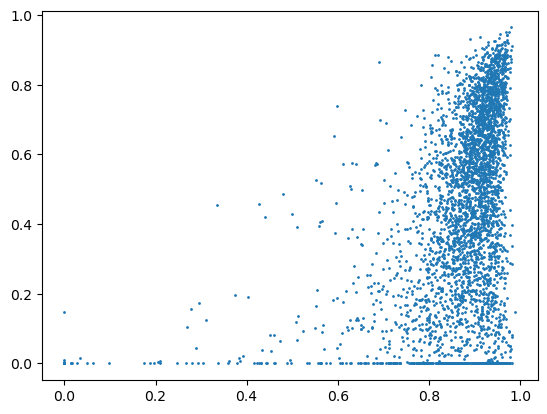

In [18]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.show()

In [19]:
zero_f1_ids = np.where(F1_scores[:, 1] == 0)[0]
print(len(zero_f1_ids))

380


In [20]:
f1_ids_not_zero = np.where(F1_scores[:, 1] != 0)[0]
print(len(f1_ids_not_zero))

3370


In [27]:
high_f1_ids = np.where(F1_scores[:, 1] > 0.85)[0]
print(len(high_f1_ids))

160


In [21]:
np.nanmedian(EI_consis)

0.9010413

In [22]:
np.nanmedian(EI_consis[f1_ids_not_zero])

0.9037818

In [23]:
low_f1_high_consis_ids = np.where((F1_scores[:, 1] < 0.2) & (F1_scores[:, 1] > 0) & (EI_consis > 0.8))[0]
print(len(low_f1_high_consis_ids))

353


In [ ]:
offset = 20
num_samples = 10
for i in high_f1_ids[offset:offset+num_samples]:
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(H_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(H_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()